# **Combined model in d = 3** — Allen-Cahn $\oplus$ Model B $\oplus$ KPZ

The full multi-derivative-vertex theory at **three spatial dimensions**:

$$\partial_t\phi = -\mu\phi + D\,\nabla^2\phi
  \underbrace{-\,\lambda\phi^3}_{\text{Allen-Cahn}}
  \underbrace{+\,g\,\nabla^2(\phi^2)}_{\text{Model B}}
  \underbrace{+\,\tfrac{\kappa}{2}(\nabla\phi)^2}_{\text{KPZ}} + \eta,
  \qquad (\nabla\phi)^2 = \sum_{i=1}^{3}(\partial_i\phi)^2,\quad d=3.$$

This stresses **everything at once**: three vertex types (a plain `φ³`, a composite
`∇²(φ²)`, and a per-leg `(∇φ)²`), the **per-vertex form-factor table** (mixed
modes in one theory), and the **d=3 transverse-moment loop average** (the `L·d`-dim
Gauss–Hermite, validated vs brute `∫d³ℓ`).  "Does it run?" is the question.

> **d=3 is UV-strong.** The free `⟨φ²⟩` is already UV-divergent (cutoff-set), and
> the same-signature Model B × KPZ cross makes the 1-loop **even more**
> cutoff-sensitive — so the *bare* numbers are cutoff-dependent (they need
> renormalisation); the point here is that the machinery composes and computes.

In [1]:
import os, sys, time
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))   # nb_support engine on path
os.chdir(os.path.join(_root, 'notebooks'))
import numpy as np
import matplotlib.pyplot as plt
import nb_support as nb
from models.spatial_field_3d_sim import simulate_3d, radial_correlator_3d

def order_label(ell):
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

# mass, diffusion, φ³ (Allen-Cahn), ∇²(φ²) (Model B), (∇φ)² (KPZ), noise temp
mu, D, lam, g, kpz, T = 1.0, 1.0, 0.1, 0.1, 0.2, 1.0

# The combined Allen-Cahn ⊕ Model B ⊕ KPZ d=3 theory now lives in
# theories/combined_allencahn_modelb_kpz_3d.theory.py (built verbatim from the
# former inline TheoryBuilder).  nb.load_theory returns (model dict, module).
model, mod = nb.load_theory('combined_allencahn_modelb_kpz_3d')

## 0. Choose the order + parameters

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 1      # 0 = tree, 1 = +1-loop  (d=3 loops are heavier)
K_EXTERNAL = 2
VERBOSE    = False
# ===========================================================================
xs = np.linspace(0.0, 5.0, 13)            # radial separations r ≥ 0
kw = dict(k=K_EXTERNAL, external_fields=[('phi', 1), ('phi', 1)], spatial_grid=xs,
          tau_max=0.0, tau_step=1.0, verbose=VERBOSE, use_cache=False, mf_dae_n_starts=4)
fund = {'mu': mu, 'D': D, 'lam': lam, 'g': g, 'kpz': kpz, 'T': T}
orders = list(range(0, MAX_ELL + 1))
# d=3 free continuum reference (r>0): Yukawa C₀(r)=(T/4πD)·e^{−r√(μ/D)}/r
# (C₀(0)=⟨φ²⟩ is UV-divergent in d=3 — cutoff-set, so we only draw r>0).
kap = np.sqrt(mu / D)
C0_yuk = np.where(xs > 0, T / (4 * np.pi * D) * np.exp(-kap * np.maximum(xs, 1e-9)) / np.maximum(xs, 1e-9), np.nan)

## 1. Theory — combined, multi-vertex, **d=3**

In [3]:
# The per-vertex form-factor table + the d=3 transverse-moment loop average let
# this 3-vertex, mixed-mode theory compute.  (The same-signature Model B × KPZ
# cross is UV-divergent in d=3 — the bare 1-loop is cutoff-dependent.)
#
# Run through the shared engine: nb.run -> compute_cumulants with the SAME
# k / external_fields / spatial_grid / fundamental as before.  external_fields
# is passed as ('phi',1) (normalized internally to the model's 'dphi' leg), so
# the numerics are identical to the old inline call.
curves, theory_ok = {}, True
try:
    for ell in orders:
        t0 = time.time()
        cfg = nb.Config(k=K_EXTERNAL, max_ell=ell,
                        external_fields=[('phi', 1), ('phi', 1)],
                        fundamental=fund, spatial_grid=xs,
                        tau_max=0.0, tau_step=1.0)
        out = nb.run(model, cfg, mod)
        mid = out['C_tau_x'].shape[0] // 2
        curves[ell] = np.real(out['C_tau_x'])[mid]
        si = out.get('spatial_info', {}) or {}
        print('%-26s C(0,0) = %.4f   mode = %s   (%.0fs)'
              % (order_label(ell), curves[ell][0], si.get('vertex_mode', '—'), time.time() - t0))
    print('\n[combined d=3 RUNS: 3 vertex types, mixed modes, transverse-moment GH at d=3]')
except Exception as e:
    theory_ok = False
    import traceback
    print('THEORY raised: %s' % e)
    print(traceback.format_exc().splitlines()[-2])

tree                       C(0,0) = 1.9481   mode = —   (1s)


tree + 1-loop              C(0,0) = -1783.1120   mode = composite+perleg   (165s)

[combined d=3 RUNS: 3 vertex types, mixed modes, transverse-moment GH at d=3]


## 2. Simulation — the full 3-D SPDE

In [4]:
# Full combined 3-D SPDE (heavier — N³ sites): −λφ³, +g∇²(φ²), +(κ/2)(∇φ)².
snaps, meta = simulate_3d(L=10.0, N=20, mu=mu, D=D, T=T,
                          lam=lam, g_lap=g, lam_kpz=kpz, dt=0.005,
                          n_steps=40000, burn_in=10000, record_every=20, seed=1)
ok = np.all(np.isfinite(snaps)) and np.max(np.abs(snaps)) < 30
if not ok:
    print('WARNING: 3-D sim blew up — reduce a coupling (g is the stiff one) or dt.')
mean = float(np.mean(snaps))                          # KPZ excess velocity ≠ 0
rc, Cr = radial_correlator_3d(snaps, meta, n_bins=20, r_max=5.0)
Cr_conn = Cr - mean ** 2                              # connected C(r)
print('combined 3-D SPDE ran:  ⟨φ⟩ (KPZ excess velocity) = %.4f' % mean)
print('   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = %.4f   max|φ| = %.2f' % (Cr_conn[0], float(np.max(np.abs(snaps)))))

combined 3-D SPDE ran:  ⟨φ⟩ (KPZ excess velocity) = 0.2045
   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = 0.4053   max|φ| = 3.82


## 3. Result

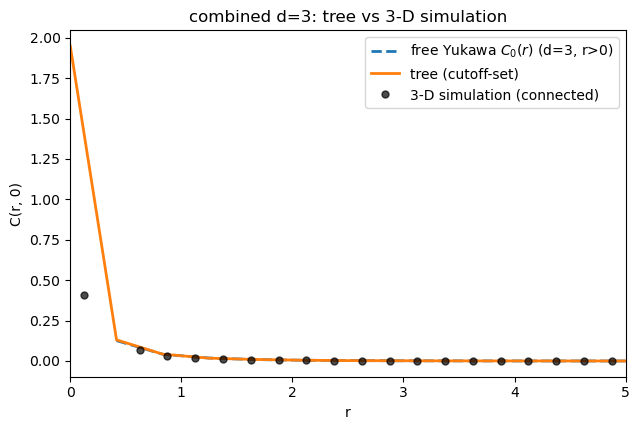

1-loop C(0,0) = -1783.1  ← UV-DIVERGENT at d=3: the same-signature Model B
  ∇²(φ²) × KPZ (∇φ)² cross raises the superficial degree of divergence, so the
  BARE 1-loop is cutoff-dominated (off the plot scale) — it needs renormalisation.

The point: the full 3-vertex, mixed-mode theory COMPUTES at d=3 (it ran).


In [5]:
# The d=3 1-loop is UV-divergent (same-sig Model B × KPZ cross) ⇒ off-scale;
# plot the (cutoff-set but finite) tree against the sim, and report 1-loop in text.
fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.plot(xs, C0_yuk, '--', lw=2, color='C0', label=r'free Yukawa $C_0(r)$ (d=3, r>0)')
if theory_ok and 0 in curves:
    ax.plot(xs, curves[0], '-', lw=2, color='C1', label='tree (cutoff-set)')
ax.plot(rc, Cr_conn, 'o', ms=5, color='k', alpha=0.7, label='3-D simulation (connected)')
ax.set_xlabel('r'); ax.set_ylabel('C(r, 0)'); ax.set_xlim(0, xs.max())
ax.set_title('combined d=3: tree vs 3-D simulation'); ax.legend()
plt.tight_layout(); plt.show()

if theory_ok and (1 in curves):
    print('1-loop C(0,0) = %.1f  ← UV-DIVERGENT at d=3: the same-signature Model B' % curves[1][0])
    print('  ∇²(φ²) × KPZ (∇φ)² cross raises the superficial degree of divergence, so the')
    print('  BARE 1-loop is cutoff-dominated (off the plot scale) — it needs renormalisation.')
print('\nThe point: the full 3-vertex, mixed-mode theory COMPUTES at d=3 (it ran).')

## Summary

The **full combined model runs at d=3** — three vertex types (`φ³`, composite
`∇²(φ²)`, per-leg `(∇φ)²`) with mixed `composite`/`perleg` modes, summed by the
per-vertex form-factor table, with the loop integral the **`L·d`-dim
transverse-moment Gauss–Hermite** average (validated vs brute `∫d³ℓ`).  The 3-D
simulator (`spatial_field_3d_sim`) integrates the same SPDE; the KPZ excess
velocity `⟨φ⟩=(κ/2μ)⟨(∇φ)²⟩` is the cutoff-robust cross-check.

**d=3 caveat (physics):** the free `⟨φ²⟩` is UV-divergent (cutoff-set) and the
same-signature Model B × KPZ cross makes the 1-loop more so — the *bare* numbers
are cutoff-dependent (need renormalisation).  Theory and sim use different
regulators (Schwinger vs lattice), so the bare magnitudes differ; the deliverable
is that the machinery **composes and computes** in d=3.  See `docs/spatial_d_ge_2.md`.